# ReLU

In [4]:
import numpy as np

In [5]:
inputs = [0, 2, -1, 3.3, -2.7, 1.1, 2.2, -100]

In [6]:
output = []

for i in inputs:
    if i > 0:
        output.append(i)
    else:
        output.append(0)

print(output)

[0, 2, 0, 3.3, 0, 1.1, 2.2, 0]


In [7]:
output = np.maximum(0, inputs)
print(output)

[0.  2.  0.  3.3 0.  1.1 2.2 0. ]


In [8]:
import matplotlib.pyplot as plt
from nnfs.datasets import spiral_data
import nnfs
nnfs.init()

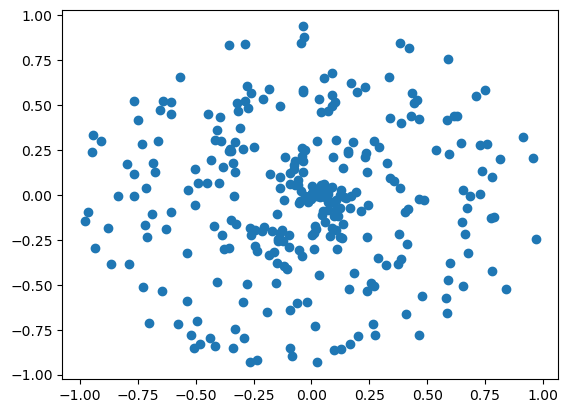

In [9]:
X, y = spiral_data(samples=100, classes=3)
plt.scatter(X[:, 0], X[:, 1])

In [10]:
class Layer_Dense:
    def __init__(self, n_inputs, n_neurons):
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))
        pass

    def forward(self, inputs):
        self.output = np.dot(inputs, self.weights) + self.biases
        pass

In [11]:
class Activation_ReLU:
    def forward(self, inputs):
        self.output = np.maximum(0, inputs)

In [12]:
X, y = spiral_data(samples=100, classes=3)

dense1 = Layer_Dense(2, 3)

activation1 = Activation_ReLU()

dense1.forward(X)

activation1.forward(dense1.output)

In [13]:
print(activation1.output[:5])

[[0.000000e+00 0.000000e+00 0.000000e+00]
 [0.000000e+00 0.000000e+00 0.000000e+00]
 [2.992573e-06 0.000000e+00 0.000000e+00]
 [8.951018e-05 0.000000e+00 0.000000e+00]
 [0.000000e+00 0.000000e+00 0.000000e+00]]


# Softmax

In [14]:
layer_outputs = [4.8, 1.21, 2.385]

E = 2.71828182846

exp_values = []

for output in layer_outputs:
    exp_values.append(E ** output)

print('exponentiated values:')
print(exp_values)

exponentiated values:
[121.51041751893969, 3.3534846525504487, 10.85906266492961]


In [15]:
norm_base = sum(exp_values)
norm_values = []

for value in exp_values:
    norm_values.append(value / norm_base)

print('Normalized exponentiated values:')
print(norm_values)
print('Sum of normalized values:', sum(norm_values))

Normalized exponentiated values:
[0.8952826639573506, 0.024708306782070668, 0.08000902926057876]
Sum of normalized values: 1.0


In [16]:
layer_outputs = [4.8, 1.21, 2.385]

exp_values = np.exp(layer_outputs)
print('exponentiated values:')
print(exp_values)

norm_values = exp_values / np.sum(exp_values)
print('normalized exponentiated values:')
print(norm_values)
print('sum of normalized values:', np.sum(norm_values))

exponentiated values:
[121.51041752   3.35348465  10.85906266]
normalized exponentiated values:
[0.89528266 0.02470831 0.08000903]
sum of normalized values: 0.9999999999999999


In [18]:
exp_values = np.exp(inputs)
probabilites = exp_values / np.sum(exp_values, keepdims=True)

In [20]:
import numpy as np
layer_outputs = np.array([[4.8, 1.21, 2.385], [8.9,-1.81, 0.2], [1.41, 1.051, 0.026]])
print('Sum without axis')

print(np.sum(layer_outputs))
print('This will be identical to the above since default is None:')

print(np.sum(layer_outputs, axis=None))

Sum without axis
18.172
This will be identical to the above since default is None:
18.172


In [23]:
print(np.sum(layer_outputs, axis=0))

[15.11   0.451  2.611]


In [24]:
print('sum the rows instead')
for i in layer_outputs:
    print(sum(i))

sum the rows instead
8.395
7.29
2.4869999999999997
